In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np  

In [2]:
# load the dataset


df = pd.read_csv(r"C:\Users\user\Desktop\AI automation\project_5\data-export (1).csv")

df.head()

,# ----------------------------------------,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044


In [5]:
df.columns = df.iloc[0]
df =df.drop(index= 0).reset_index(drop=True)
df.columns =["channel group", "DateHour", "Users", "Sessions", "Engaged Sessions", "Average engagement time per session", "Engaged sessions per user", "Events per session", "Engagement rate", "Event count"]
df.head()

,channel group,DateHour,Users,Sessions,Engaged Sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
1,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
2,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
3,Organic Social,2024041720,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001
4,Organic Social,2024041721,160,206,103,59.31553398058250,0.64375,4.694174757281550,0.5,967


In [7]:
df.isnull().sum()

channel group                          0
DateHour                               0
Users                                  0
Sessions                               0
Engaged Sessions                       0
Average engagement time per session    0
Engaged sessions per user              0
Events per session                     0
Engagement rate                        0
Event count                            0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3181 entries, 0 to 3180
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   channel group                        3181 non-null   object
 1   DateHour                             3181 non-null   object
 2   Users                                3181 non-null   object
 3   Sessions                             3181 non-null   object
 4   Engaged Sessions                     3181 non-null   object
 5   Average engagement time per session  3181 non-null   object
 6   Engaged sessions per user            3181 non-null   object
 7   Events per session                   3181 non-null   object
 8   Engagement rate                      3181 non-null   object
 9   Event count                          3181 non-null   object
dtypes: object(10)
memory usage: 248.6+ KB


In [12]:
df['DateHour'] = pd.to_datetime(df['DateHour'], format="%Y%m%d%H",errors='coerce')
df.head()

,channel group,DateHour,Users,Sessions,Engaged Sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Organic Social,2024-04-17 19:00:00,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
1,Direct,2024-04-17 23:00:00,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
2,Organic Social,2024-04-17 18:00:00,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
3,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001
4,Organic Social,2024-04-17 21:00:00,160,206,103,59.31553398058250,0.64375,4.694174757281550,0.5,967


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3181 entries, 0 to 3180
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   channel group                        3181 non-null   object        
 1   DateHour                             3181 non-null   datetime64[ns]
 2   Users                                3181 non-null   object        
 3   Sessions                             3181 non-null   object        
 4   Engaged Sessions                     3181 non-null   object        
 5   Average engagement time per session  3181 non-null   object        
 6   Engaged sessions per user            3181 non-null   object        
 7   Events per session                   3181 non-null   object        
 8   Engagement rate                      3181 non-null   object        
 9   Event count                          3181 non-null   object        
dtypes: datetime6

In [13]:
numeric_cols = df.columns.drop(['channel group', 'DateHour'])
df[numeric_cols] = df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
df["Hour"] = df["DateHour"].dt.hour

In [14]:
df.head()

,channel group,DateHour,Users,Sessions,Engaged Sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
0,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
1,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
2,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
3,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20
4,Organic Social,2024-04-17 21:00:00,160,206,103,59.315534,0.643750,4.694175,0.500000,967,21


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3181 entries, 0 to 3180
Data columns (total 11 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   channel group                        3181 non-null   object        
 1   DateHour                             3181 non-null   datetime64[ns]
 2   Users                                3181 non-null   int64         
 3   Sessions                             3181 non-null   int64         
 4   Engaged Sessions                     3181 non-null   int64         
 5   Average engagement time per session  3181 non-null   float64       
 6   Engaged sessions per user            3181 non-null   float64       
 7   Events per session                   3181 non-null   float64       
 8   Engagement rate                      3181 non-null   float64       
 9   Event count                          3181 non-null   int64         
 10  Hour        

In [16]:
df.describe()

,DateHour,Users,Sessions,Engaged Sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
count,3181,3181.000000,3181.000000,3181.000000,3181.000000,3181.000000,3181.000000,3181.000000,3181.000000,3181.000000
mean,2024-04-20 01:18:31.348632576,41.874568,51.114429,28.289217,66.650591,0.606449,4.675970,0.503404,241.907891,11.803521
min,2024-04-06 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,2024-04-13 02:00:00,20.000000,24.000000,13.000000,32.097378,0.561404,3.750000,0.442857,103.000000,6.000000
50%,2024-04-20 02:00:00,42.000000,51.000000,27.000000,49.040404,0.666667,4.410256,0.545455,226.000000,12.000000
75%,2024-04-26 22:00:00,60.000000,71.000000,41.000000,71.500000,0.750000,5.218182,0.633333,339.000000,18.000000
max,2024-05-03 23:00:00,208.000000,267.000000,132.000000,4525.000000,2.000000,56.000000,1.000000,1147.000000,23.000000
std,NaN,29.383942,36.661139,20.551668,127.220206,0.264064,2.795667,0.228241,183.318978,6.884907


# session and user over time


In [17]:
sns.set_style("whitegrid")

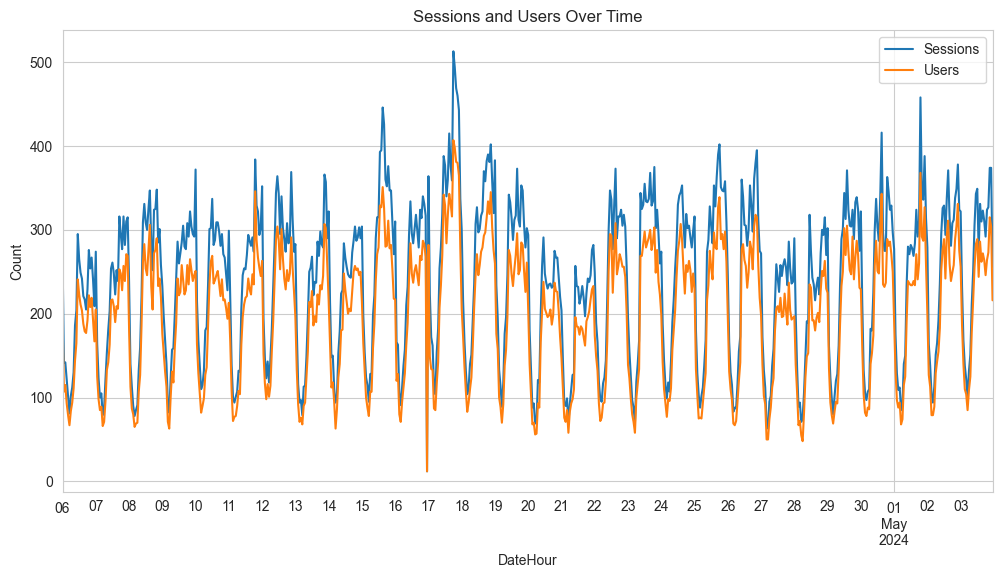

In [19]:
plt.figure(figsize=(12, 6))
df.groupby('DateHour')[["Sessions", "Users"]].sum().plot(ax=plt.gca())
plt.title("Sessions and Users Over Time")
plt.xlabel("DateHour")
plt.ylabel("Count")
plt.show()

- conclusion: this is the session and user over time

# total user by channels

C:\Users\user\AppData\Local\Temp\ipykernel_4612\1223728820.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='channel group', y='Users', estimator=np.sum, palette='viridis')


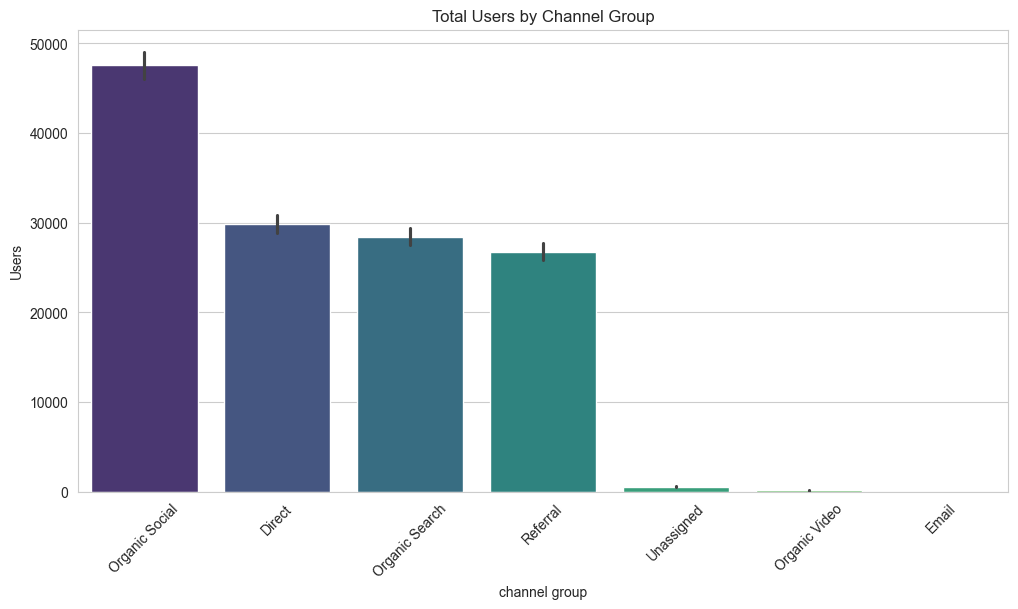

In [21]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='channel group', y='Users', estimator=np.sum, palette='viridis')
plt.title("Total Users by Channel Group")
plt.xticks(rotation=45)
plt.show()

- conclusion work on unassigned, organic video, email

In [22]:
df.head()

,channel group,DateHour,Users,Sessions,Engaged Sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
0,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
1,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
2,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
3,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20
4,Organic Social,2024-04-17 21:00:00,160,206,103,59.315534,0.643750,4.694175,0.500000,967,21


# average engagment time by channel

C:\Users\user\AppData\Local\Temp\ipykernel_4612\39580862.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='channel group', y='Average engagement time per session', estimator=np.mean, palette='magma')


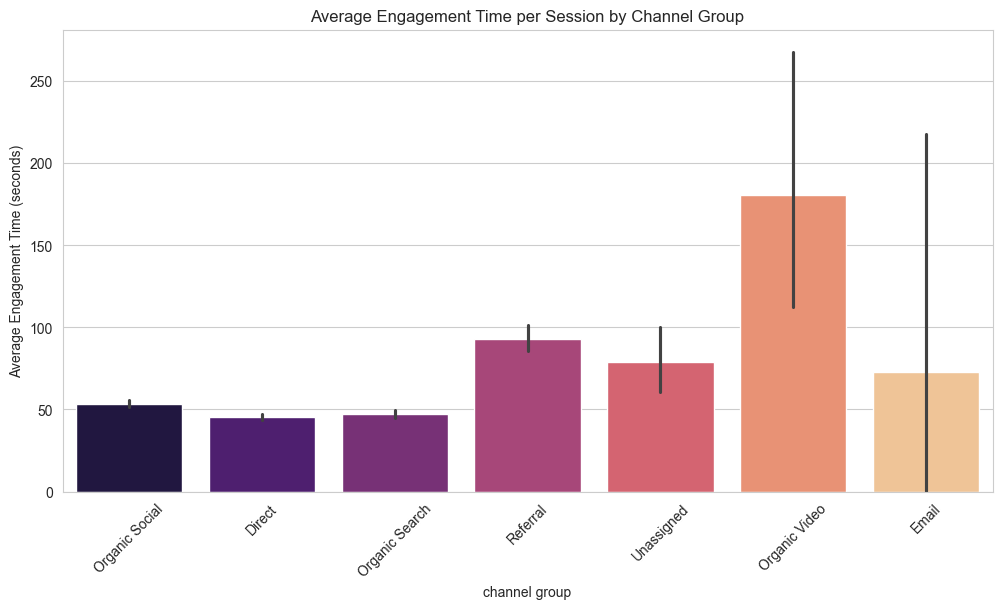

In [24]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='channel group', y='Average engagement time per session', estimator=np.mean, palette='magma')
plt.title("Average Engagement Time per Session by Channel Group")
plt.xticks(rotation=45)
plt.ylabel("Average Engagement Time (seconds)")
plt.show()

In [25]:
df.head()

,channel group,DateHour,Users,Sessions,Engaged Sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
0,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
1,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
2,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
3,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20
4,Organic Social,2024-04-17 21:00:00,160,206,103,59.315534,0.643750,4.694175,0.500000,967,21


# Egagement rate Distribution by Channel

C:\Users\user\AppData\Local\Temp\ipykernel_4612\3380833188.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='channel group', y='Engagement rate', palette='coolwarm')


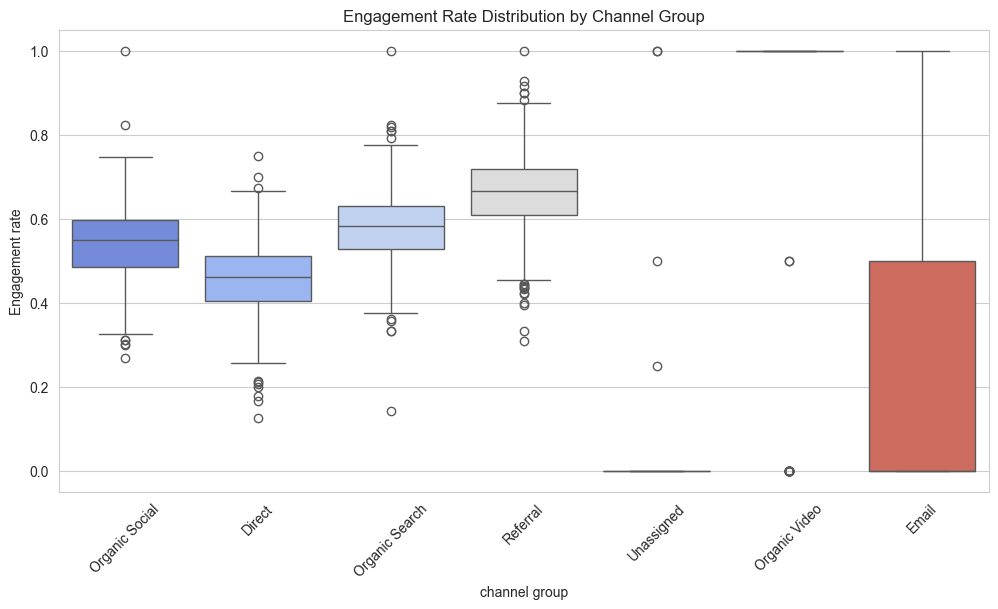

In [26]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='channel group', y='Engagement rate', palette='coolwarm')
plt.title("Engagement Rate Distribution by Channel Group")
plt.xticks(rotation=45)
plt.show()

# Engaged vs non engaged session

In [27]:
df.head()

,channel group,DateHour,Users,Sessions,Engaged Sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
0,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
1,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
2,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
3,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20
4,Organic Social,2024-04-17 21:00:00,160,206,103,59.315534,0.643750,4.694175,0.500000,967,21


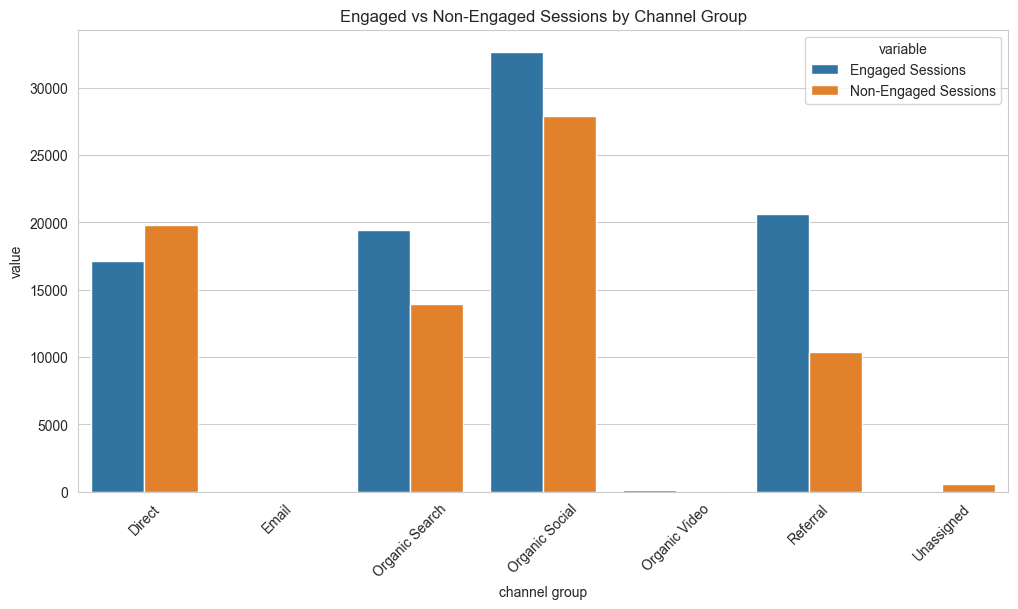

In [29]:
session_df = df.groupby('channel group')[["Sessions", "Engaged Sessions"]].sum().reset_index()

session_df["Non-Engaged Sessions"] = (
    session_df["Sessions"] - session_df["Engaged Sessions"]
)

session_df = session_df.melt(
    id_vars='channel group',
    value_vars=['Engaged Sessions', 'Non-Engaged Sessions']
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=session_df,
    x='channel group',
    y='value',
    hue="variable"
)

plt.title("Engaged vs Non-Engaged Sessions by Channel Group")
plt.xticks(rotation=45)

plt.show()

- conclusion: work more on Direct channel

# Traffic by hour and channel

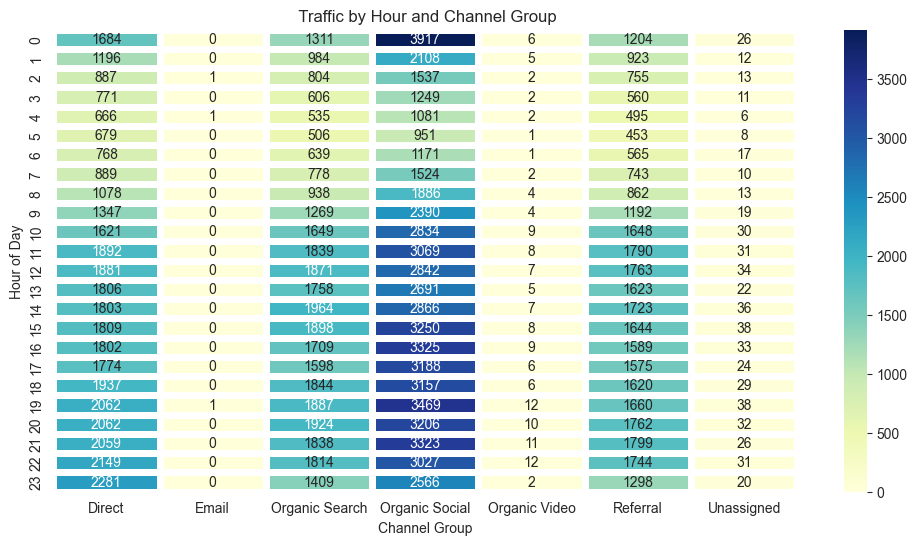

In [31]:
# draw a heatmap of Traffic by hour and channel
heatmap_data = df.groupby(['Hour', 'channel group'])['Sessions'].sum().unstack().fillna(0)
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='YlGnBu',  linewidth= 5, annot=True, fmt=".0f")
plt.title(" Traffic by Hour and Channel Group")
plt.xlabel("Channel Group")
plt.ylabel("Hour of Day")
plt.show()

# engagement rate vs session over time 

In [35]:
df.head()

,channel group,DateHour,Users,Sessions,Engaged Sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
0,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
1,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
2,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
3,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20
4,Organic Social,2024-04-17 21:00:00,160,206,103,59.315534,0.643750,4.694175,0.500000,967,21


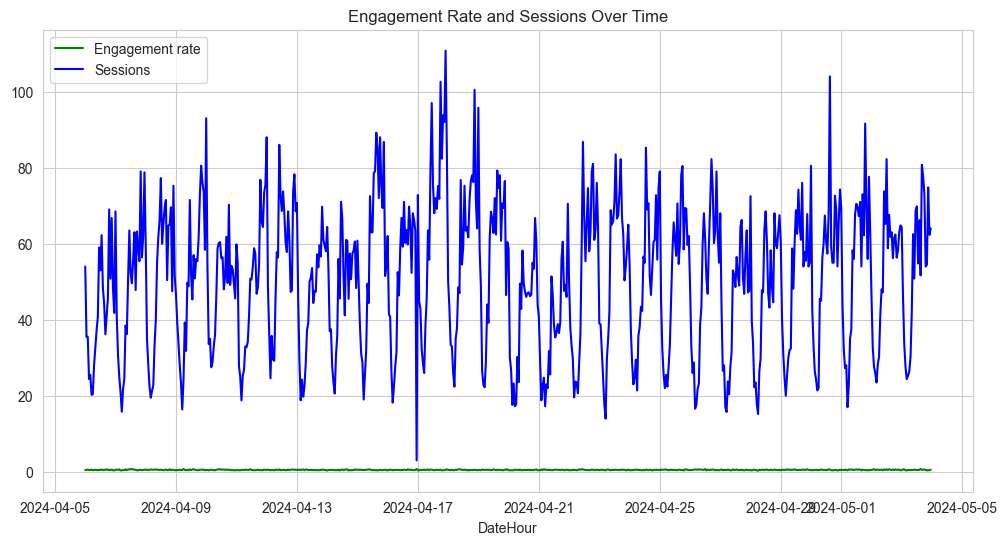

In [ ]:
df_plot =df.groupby('DateHour')[["Engagement rate", "Sessions"]].mean().reset_index()
plt.figure(figsize=(12, 6))
plt.plot(df_plot['DateHour'], df_plot['Engagement rate'], label='Engagement r


' \
'

ate', color='green')
plt.plot(df_plot['DateHour'], df_plot['Sessions'], label='Sessions', color='blue')
plt.title("Engagement Rate and Sessions Over Time")
plt.xlabel("DateHour")
plt.legend()
plt.grid(True)
plt.show()